# 3장 2강: 피어슨 상관계수의 의미와 한계 — 실습문제

## 실습 목표

- 두 연속형 변수의 피어슨 상관계수와 p-value를 계산하고 방향·강도를 해석합니다.
- 결정계수 $r^2$의 의미를 올바르게 설명합니다.
- 산점도를 함께 확인하여 이상치와 비선형 관계가 피어슨 상관계수에 미치는 영향을 판단합니다.
- 상관관계만으로 인과관계를 주장할 수 없는 이유와 가능한 혼란변수를 설명합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, SciPy, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `LotArea`
- 모든 판단은 유의수준 $\alpha=0.05$를 기준으로 합니다.

## 실습 준비

아래 셀을 실행해 데이터를 불러오고 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

data_candidates = [
    Path("ames_housing.csv"),
    Path("upload/ames_housing.csv"),]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적과 매매가격의 피어슨 상관분석

`GrLivArea`와 `SalePrice`의 선형 관계를 분석하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. `stats.pearsonr()`로 피어슨 상관계수 $r$과 p-value를 계산하세요.
3. $r^2$을 계산하세요.
4. 축 이름과 제목이 있는 산점도를 그리세요.
5. 아래 질문에 문장으로 답하세요.

### 질문

1. 상관관계의 방향과 강도는 어떠한가요?
 - r값이 양수값이고 절대값이 0.71이므로 비교적 강한 양의 상관관계

2. p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
 - p-value가 0.05보다 작으므로 상관계수가 0일 것이라는 귀무가설을 기각한다.
 - 두 변수는 통계적으로 유의하다.
 
3. $r^2$은 이 관계에서 무엇을 의미하나요?
 - 같은 자료에 생활면적을 설명변수로 하는 절편을 포함하여 최소제곱 단순 선형회귀를 적합하여 결정계수 r^2이 약 0.50이다.
 - 즉 생활면적을 이용한 직선 모형이 이 자료의 가격 변동을 약 50.2%로 설명한다.

4. 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?
 - ㄴㄴ 이미 존재하는 주택의 특성을 간찰한 데이터에서 다른 외부 요인 변수를 분리하여 확인하지 못했다.


표본 수: 1460
피어슨 상관계수 r: 0.7086
p-value: 4.5180e-223
r²: 0.5021
유의성 판단: 유의힘


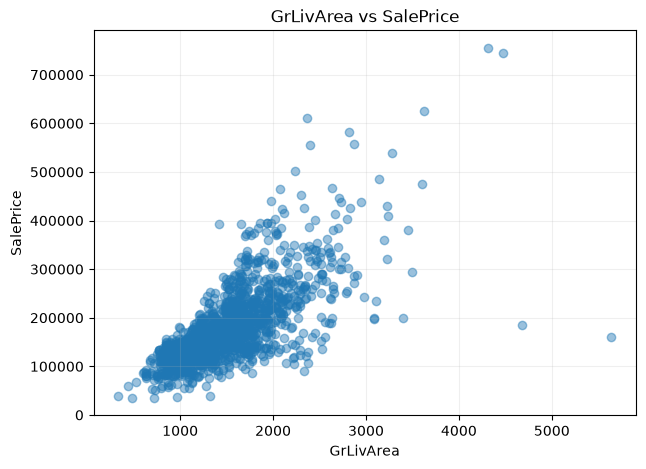

In [2]:
# 여기에 코드를 작성하세요.
area_price = df[["GrLivArea", "SalePrice"]].dropna()

r, p_value = stats.pearsonr(
    area_price["GrLivArea"],
    area_price["SalePrice"]
)

r_squared = r ** 2

print(f"표본 수: {len(area_price)}")
print(f"피어슨 상관계수 r: {r:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"r²: {r_squared:.4f}")
print("유의성 판단:", "유의힘" if p_value <= alpha else "유의하지 않음")

plt.figure(figsize=(7, 5))
plt.scatter(area_price["GrLivArea"], area_price["SalePrice"], alpha=0.45)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.grid(alpha=0.2)
plt.show()

---

## 필수 2. 피어슨 상관계수의 두 가지 한계 확인

피어슨 상관계수가 이상치에 민감하고 비선형 관계를 놓칠 수 있다는 점을 확인하세요.

### A. 이상치의 영향

1. `GrLivArea`, `SalePrice`에서 `random_state=42`로 50행을 표본 추출하세요.
2. 표본의 $r$과 p-value를 계산하세요.
3. 학습용 가상 이상치 `(GrLivArea=6000, SalePrice=50000)` 한 행을 표본에만 추가하세요. 원본 `df`는 변경하지 마세요.
4. 이상치 추가 후 $r$과 p-value를 다시 계산하세요.
5. 추가 전후 산점도를 나란히 그리고 결과를 비교하세요.

### B. 비선형 관계

1. `x = [-3, -2, -1, 0, 1, 2, 3]`, `y = x**2`를 만드세요.
2. $x$와 $y$의 $r$과 p-value를 계산하고 산점도를 그리세요.

### 질문

1. 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
 - r 0.71 > 0.26으로 감소, p-value는 0.05미만에서 0.06으로 증가했다.
 - 귀무가설을 기각함에서 귀무가설을 기각할 수 없음으로 판단이 변경 

2. 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
 - 요약값만 보면 변화의 원인을 한눈에 파악하기 어려움
 - 산점도는 멀리 떨어진 점들과 일부 선형관계를 한눈에 파악하기 쉬움
 - 이 점은 이상치도 한눈에 파악하기 쉽다는 것을 알려 줌

3. $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
 - 피어슨 r은 직선 형태의 관계를 요약함
 - u자형 그래프의 왼쪽과 오른쪽은 서로 반대 방향의 선형 움직임을 보이기 때문에 0에 가까움

4. `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?
 - ㄴㄴ r=0은 선형관계가 거의 없다는 뜻, 비선형관계는 존재할 수 있다.


[이상치 추가 전]
r = 0.7059, p-value = 1.0263e-08
[이상치 추가 후]
r = 0.2602, p-value = 0.0651


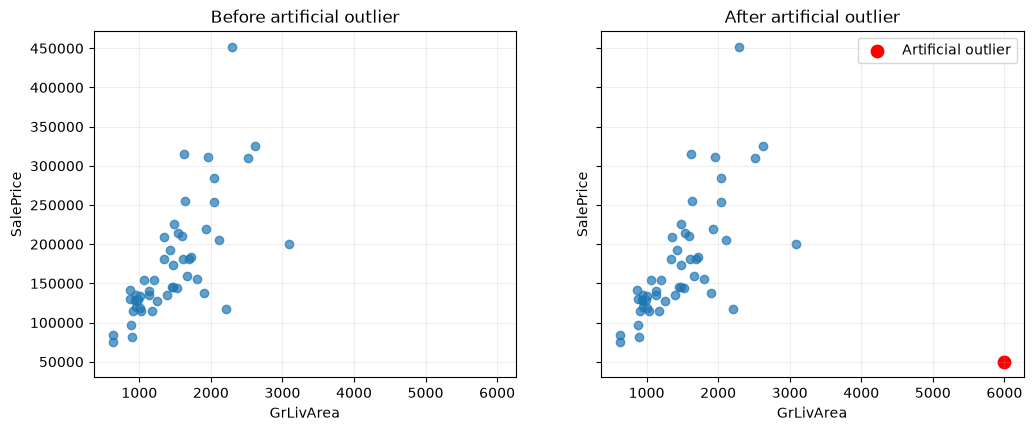

[비선형 관계]
r = 0.0000, p-value = 1.0000


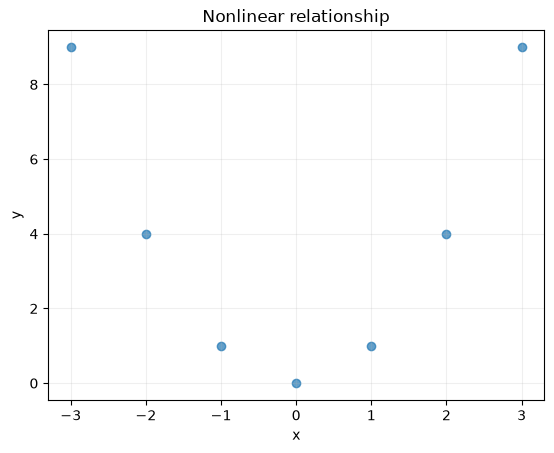

In [4]:
# 여기에 코드를 작성하세요.
# A
sample_50 = df[["GrLivArea", "SalePrice"]].dropna().sample(n=50, random_state=42)

r_before, p_before = stats.pearsonr(
    sample_50["GrLivArea"], sample_50["SalePrice"]
)

artificial_outlier = pd.DataFrame({"GrLivArea": [6000], "SalePrice": [50000]})
sample_with_outlier = pd.concat([sample_50, artificial_outlier], ignore_index=True)

r_after, p_after = stats.pearsonr(
    sample_with_outlier["GrLivArea"], sample_with_outlier["SalePrice"]
)

print("[이상치 추가 전]")
print(f"r = {r_before:.4f}, p-value = {p_before:.4e}")
print("[이상치 추가 후]")
print(f"r = {r_after:.4f}, p-value = {p_after:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

axes[0].scatter(sample_50["GrLivArea"], sample_50["SalePrice"], alpha=0.7)
axes[0].set_title("Before artificial outlier")

axes[1].scatter(sample_with_outlier["GrLivArea"], sample_with_outlier["SalePrice"], alpha=0.7)
axes[1].scatter([6000], [50000], color="red", s=80, label="Artificial outlier")
axes[1].set_title("After artificial outlier")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("GrLivArea")
    ax.set_ylabel("SalePrice")
    ax.grid(alpha=0.2)

plt.show()

# B
# 필수 2-B 코드를 작성하세요.
x = np.array([-3, -2, -1, 0, 1, 2, 3])
y = x ** 2

r_nonlinear, p_nonlinear = stats.pearsonr(x, y)

print("[비선형 관계]")
print(f"r = {r_nonlinear:.4f}, p-value = {p_nonlinear:.4f}")

plt.scatter(x, y, alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Nonlinear relationship")
plt.grid(alpha=0.2)
plt.show()

---

## 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

1. 관계의 방향과 강도는 어떠한가요?
  - 피어슨 상관계수는 r = 0.2638이므로 대지 면적과 매매 가격 사이에는 약한 양의 선형 관계가 있다고 볼 수 있다.

2. 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
  - 아니다. 통계적 유의성은 p-value를 통해 판단하고
    관계의 강도는 상관계수의 크기를 통해 판단하므로 같은 의미라고 볼 수 없다.

3. 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
  - 없다. 상관관계가 나타났다는 것만으로 인과관계를 판단할 수 없기 때문이다.

4. 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
  - 주택의 위치, 건축 시기

5. 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.
  - 안 된다. 두 변수 사이에 뚜렷한 U자형 관계가 있어도 증가하는 구간과 감소하는 구간이
    서로 상쇄되어 상관계수가 0에 가깝게 나타날 수 있기 때문이다.

표본 수: 1460
피어슨 상관계수 r: 0.2638
p-value: 1.1231e-24
r²: 0.0696
유의성 판단: 유의함


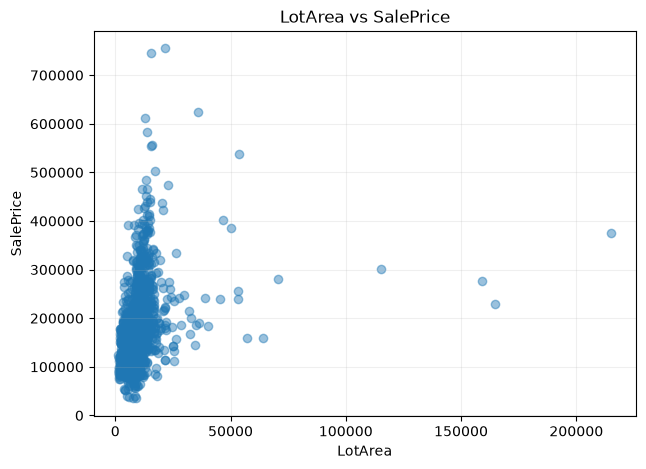

In [2]:
# 여기에 코드를 작성하세요.
alpha = 0.05

lot_price = df[["LotArea", "SalePrice"]].dropna()

r, p_value = stats.pearsonr(
    lot_price["LotArea"],
    lot_price["SalePrice"]
)

r_squared = r ** 2

print(f"표본 수: {len(lot_price)}")
print(f"피어슨 상관계수 r: {r:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"r²: {r_squared:.4f}")
print("유의성 판단:", "유의함" if p_value <= alpha else "유의하지 않음")

plt.figure(figsize=(7, 5))
plt.scatter(
    lot_price["LotArea"],
    lot_price["SalePrice"],
    alpha=0.45
)

plt.xlabel("LotArea")
plt.ylabel("SalePrice")
plt.title("LotArea vs SalePrice")
plt.grid(alpha=0.2)
plt.show()

---

## 실습 마무리

1. 어떤 문제가 있었는가?
 - 상관계수와 p-value만으로는 관계를 명확하게 규정하기 어려움.

2. 어떻게 개선했는가?
 - r, r^2, p-value, 산점도, 이상치 유/무

3.무엇을 근거로 개선되었다고 판단했는가?
 - 이상치 값 하나로 r값과 p-value가 달라지는 것을 확인했다.
 - 본 데이터의 이상치를 제거한다면 정상적인 r값과 p-value로 올바른 통계적 해석이 가능하다.

피어슨 상관계수의 숫자만 보았을 때 놓칠 수 있었던 점, 산점도와 인과적 관점을 추가해 해석이 어떻게 개선되었는지 정리하세요.
